# Bayesian Neural Network

### Introduction

This notebook demonstrates the use of Bayesian models for classification tasks, focusing on Bayesian Logistic Regression and Bayesian Neural Networks. Bayesian methods provide a probabilistic approach to machine learning, allowing for uncertainty quantification in predictions, which is particularly useful in decision-making under uncertainty.
The notebook is based on the example in https://www.pymc.io/projects/examples/en/latest/variational_inference/bayesian_neural_network_advi.html

### Objectives

#### Train Bayesian models, including:
Bayesian Logistic Regression: A probabilistic version of logistic regression.
Bayesian Neural Networks: Neural networks with Bayesian inference for parameter estimation.

#### Evaluation:

Evaluate the performance of the models using metrics such as:
Accuracy: To measure the proportion of correct predictions.
ROC-AUC: To assess the model's ability to distinguish between classes.
Visualization:

Visualize the results, including decision boundaries and uncertainty estimates, to better understand the behavior of Bayesian models.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_moons
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import scale

from pybandits.model import BayesianLogisticRegression, BayesianNeuralNetwork

%load_ext autoreload
%autoreload 2

/home/runner/.cache/pypoetry/virtualenvs/pybandits-vYJB-miV-py3.10/lib/python3.10/site-packages/pydantic/_migration.py:283: UserWarning: `pydantic.generics:GenericModel` has been moved to `pydantic.BaseModel`.
  warnings.warn(f'`{import_path}` has been moved to `{new_location}`.')


In [2]:
def plot_map(value, grid, x_test, pred, metric):
    cmap = plt.get_cmap("coolwarm")

    fig, ax = plt.subplots(figsize=(10, 6))

    # Create the contour plot
    contour = ax.contourf(*grid, value.reshape(100, 100), cmap=cmap)

    # Scatter plot for the test points
    ax.scatter(x_test[pred == 0, 0], x_test[pred == 0, 1], label="Class 0")
    ax.scatter(x_test[pred == 1, 0], x_test[pred == 1, 1], color="r", label="Class 1")

    # Add a colorbar
    cbar = plt.colorbar(contour, ax=ax)
    cbar.ax.set_ylabel(f"{metric} of Output")

    # Set axis limits and labels
    ax.set(xlim=(-3, 3), ylim=(-3, 3), xlabel="X1", ylabel="X2")

    # Add a legend
    ax.legend()

    plt.show()

## Generate data

We first generate a binary labeled data set, with a two dimensional feature space, and is not linearly separable.
We then split the data set to a training data set and a test data set.

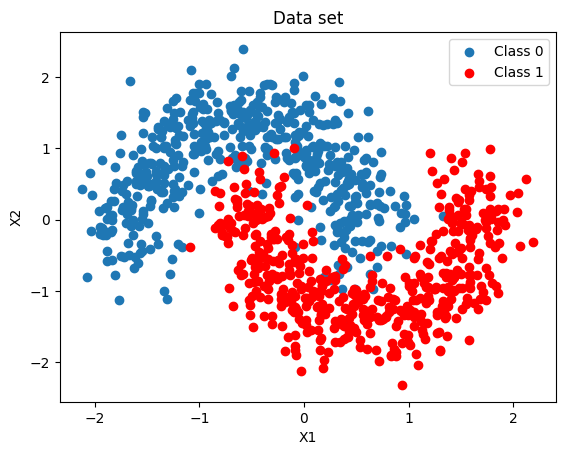

In [3]:
X, Y = make_moons(noise=0.2, random_state=0, n_samples=1000)
X = scale(X)
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.5)
y_train = y_train.tolist()
y_test = y_test.tolist()
fig, ax = plt.subplots()
ax.scatter(X[Y == 0, 0], X[Y == 0, 1], label="Class 0")
ax.scatter(X[Y == 1, 0], X[Y == 1, 1], color="r", label="Class 1")
ax.set(xlabel="X1", ylabel="X2", title="Data set")
ax.legend()

## Using Bayesian logistic regression

Using the cold_start method of BayesianLogisticRegression we can create a Bayesian Logistic Regression model with default Student-T parameters.
Default parameters values are mu (mean) = 0, sigma (standard deviation) = 10, nu (degrees of freedom) = 5.

In this case we define the model to run with Variational inference which is usually faster than MCMC.

In [4]:
blr = BayesianLogisticRegression.cold_start(n_features=2, update_method="VI", update_kwargs={"fit": {"n": 40000}})

Applying the update method will calculate the approximated posterior of the parameters, and update the model. 

In [5]:
blr.update(context=x_train, rewards=y_train)

/home/runner/.cache/pypoetry/virtualenvs/pybandits-vYJB-miV-py3.10/lib/python3.10/site-packages/pytensor/link/c/cmodule.py:2968: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(


/home/runner/.cache/pypoetry/virtualenvs/pybandits-vYJB-miV-py3.10/lib/python3.10/site-packages/rich/live.py:231: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

In order to sample from the posterior distribution, we are creating the model with the new updated parameters, and generate samples using pm.sample_prior_predictive.

We consider a point to belong to Class 1, if more than half of the samples belong to Class 1 is higher than 0.5.

In [6]:
batch_predictions = [
    blr.sample_proba(x_test) for _ in range(500)
]  # predictions are list of tuples of probabilities and corresponding weighted sums
batch_proba = np.array(
    [[proba_and_weighted_sum[0] for proba_and_weighted_sum in predictions] for predictions in batch_predictions]
)
pred_proba = batch_proba.mean(axis=0)

pred = pred_proba > 0.5

Since the Bayesian Logistic Regression model is linear, it's not able do separate the space accurately.

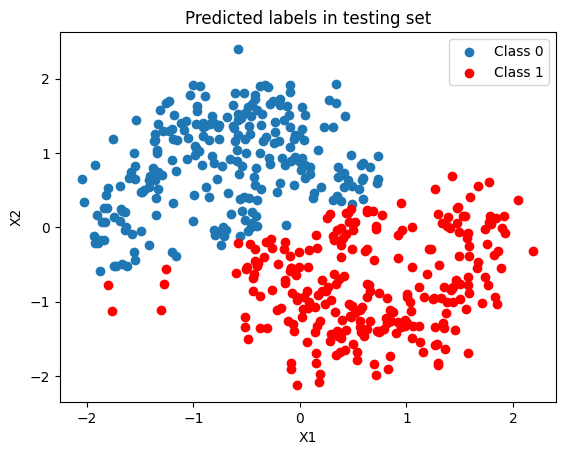

In [7]:
fig, ax = plt.subplots()
ax.scatter(x_test[pred == 0, 0], x_test[pred == 0, 1], label="Class 0")
ax.scatter(x_test[pred == 1, 0], x_test[pred == 1, 1], color="r", label="Class 1")
ax.set(title="Predicted labels in testing set", xlabel="X1", ylabel="X2")
ax.legend()

Here we calculate the accuracy and AUC score of the model

In [8]:
# Calculate accuracy
accuracy = accuracy_score(y_test, pred)
print(f"Accuracy: {accuracy}")

# Calculate AUC
auc = roc_auc_score(y_test, pred_proba)
print(f"AUC: {auc}")

Accuracy: 0.848
AUC: 0.9452860738389521


We can check the convergence by plotting the Evidence Lower Bound (ELBO) over iterations.
ELBO is a metric used in Variational Inference to measure the convergence of the approximation to the true posterior.
A higher ELBO indicates a better approximation.
https://en.wikipedia.org/wiki/Evidence_lower_bound


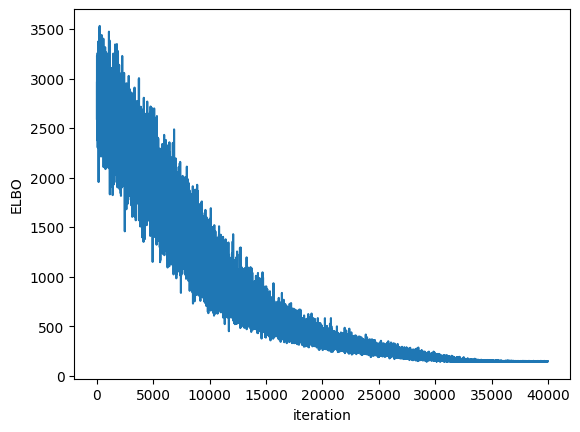

In [9]:
plt.plot(blr.approx_history)
plt.ylabel("ELBO")
plt.xlabel("iteration")
plt.show()

### Predictions + uncertainty map

In order to visualize the posterior predictive distribution, we can create a grid of points in the input space and evaluate the model at those points.

In [10]:
grid = np.mgrid[-3:3:100j, -3:3:100j].astype(float)
grid_2d = grid.reshape(2, -1).T
batch_predictions = [
    blr.sample_proba(grid_2d) for _ in range(500)
]  # predictions are list of tuples of probabilities and corresponding weighted sums
batch_proba = np.array(
    [[proba_and_weighted_sum[0] for proba_and_weighted_sum in predictions] for predictions in batch_predictions]
)
pred_proba = batch_proba.mean(axis=0)

This is the average of the output of the model

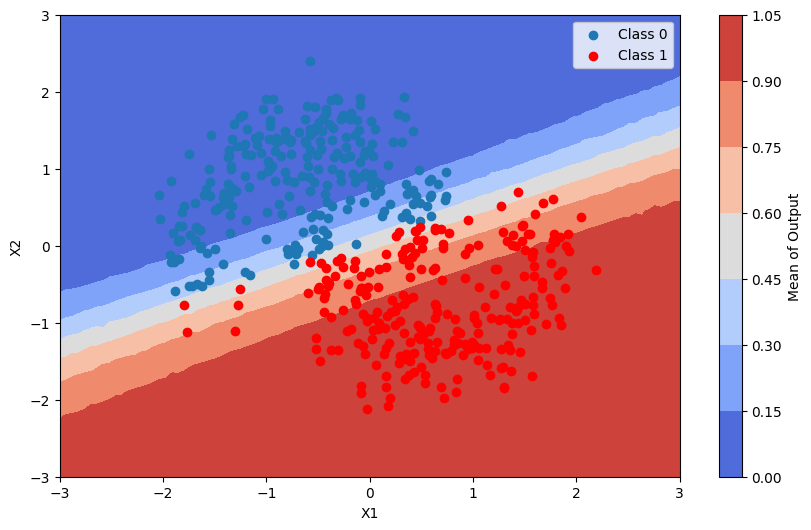

In [11]:
plot_map(pred_proba, grid, x_test, pred, "Mean")

This is the standard deviation of the output of the model

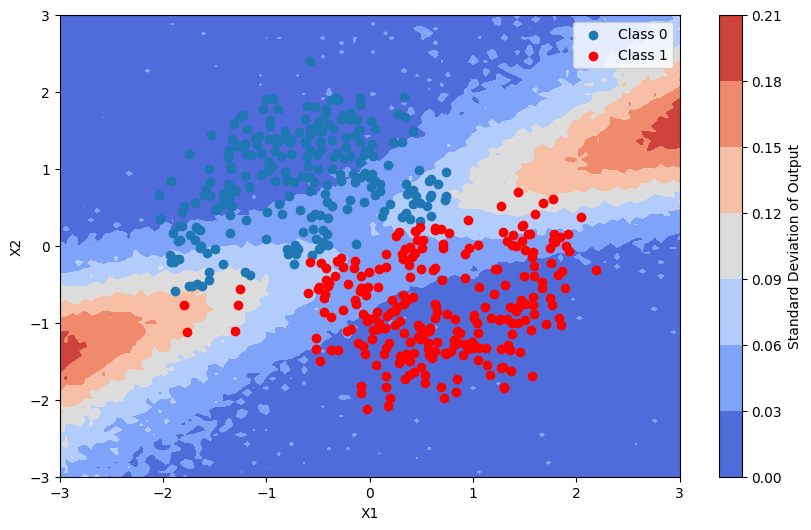

In [12]:
pred_proba_std = batch_proba.std(axis=0)

plot_map(pred_proba_std, grid, x_test, pred, "Standard Deviation")

## Using Bayesian Neural Network

In the following section we will demonstrate how a bayesian neural network (BNN) can capture complex patterns and relationships in data through multiple layers of abstraction, leading to better performance on tasks with high-dimensional features. In contrast, bayesian logistic regression is limited to linear relationships and may not effectively model intricate dependencies within the data.

In order to define the model structure, we set the hidden_dim_list=[5, 5], which means that the model structure will have a 2 layers network - with first and second layers having five neurons.

The neurons' Student-T distribution are initialized with mu = 0, sigma = 1 and nu = 5

In [13]:
dist_params_init = {"mu": 0, "sigma": 1, "nu": 5}
bnn = BayesianNeuralNetwork.cold_start(
    n_features=2,
    hidden_dim_list=[5, 5],
    update_method="VI",
    dist_params_init=dist_params_init,
    update_kwargs={"fit": {"n": 100000}},
)

Applying the update method will calculate the approximated posterior of the parameters, and update the model. 

In [14]:
bnn.update(context=x_train, rewards=y_train)

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


/home/runner/.cache/pypoetry/virtualenvs/pybandits-vYJB-miV-py3.10/lib/python3.10/site-packages/rich/live.py:231: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

We can see that the separation is much better than the bayesian logistic model.

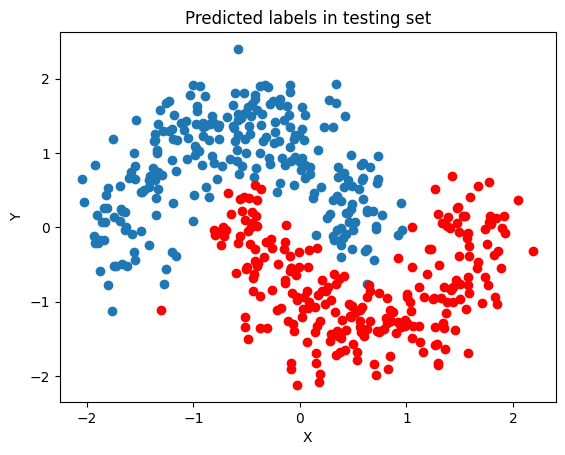

In [15]:
batch_predictions = [
    bnn.sample_proba(x_test) for _ in range(500)
]  # predictions are list of tuples of probabilities and corresponding weighted sums
batch_proba = np.array(
    [[proba_and_weighted_sum[0] for proba_and_weighted_sum in predictions] for predictions in batch_predictions]
)
pred_proba = batch_proba.mean(axis=0)

pred = pred_proba > 0.5

fig, ax = plt.subplots()
ax.scatter(x_test[pred == 0, 0], x_test[pred == 0, 1])
ax.scatter(x_test[pred == 1, 0], x_test[pred == 1, 1], color="r")
ax.set(title="Predicted labels in testing set", xlabel="X", ylabel="Y");

In [16]:
# Calculate accuracy
accuracy = accuracy_score(y_test, pred)
print(f"Accuracy: {accuracy}")

# Calculate AUC
auc = roc_auc_score(y_test, pred_proba)
print(f"AUC: {auc}")

Accuracy: 0.958
AUC: 0.9903974093845686


Plotting the ELBO convergence

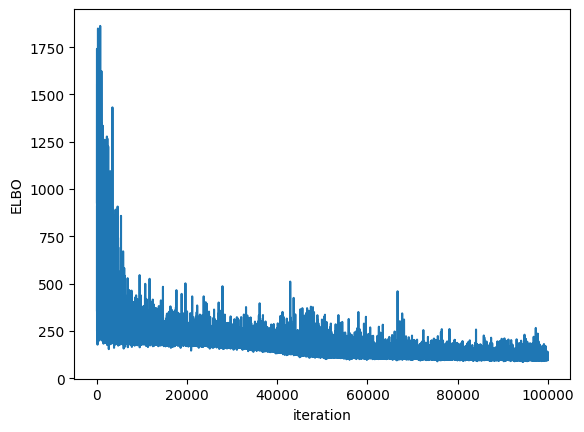

In [17]:
plt.plot(bnn.approx_history)
plt.ylabel("ELBO")
plt.xlabel("iteration")
plt.show()

### Predictions + uncertainty map

We now visualize the posterior predictive distribution of output of the bayesian neural network model


In [18]:
batch_predictions = [
    bnn.sample_proba(grid_2d) for _ in range(500)
]  # predictions are list of tuples of probabilities and corresponding weighted sums
batch_proba = np.array(
    [[proba_and_weighted_sum[0] for proba_and_weighted_sum in predictions] for predictions in batch_predictions]
)

This is the average of the output of the model

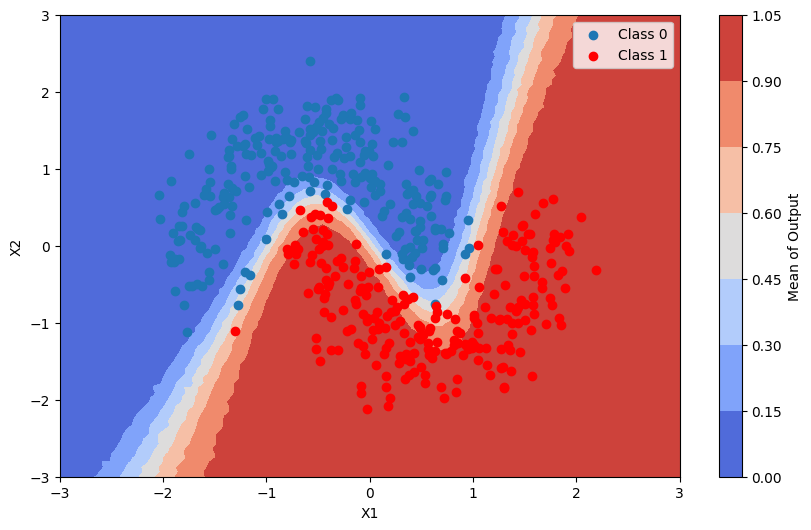

In [19]:
pred_proba_mean = batch_proba.mean(axis=0)

plot_map(pred_proba_mean, grid, x_test, pred, "Mean")

This is the standard deviation of the output of the model

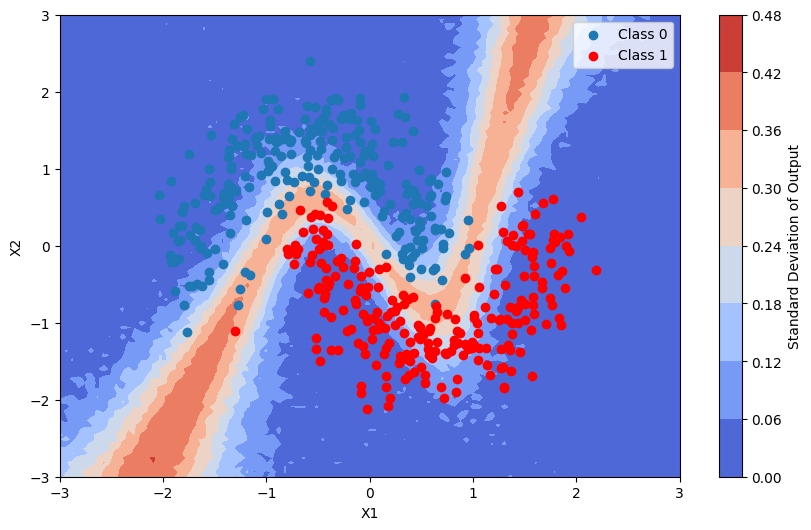

In [20]:
pred_proba_std = batch_proba.std(axis=0)

plot_map(pred_proba_std, grid, x_test, pred, "Standard Deviation")